### **This new notebook is for the 4 Features, 1 qubit per feature experiment, in total we have 4 Qubits. This notebook reutilizes a lot of code in QAOA_4F2Q_8Q.ipynb if you want to get a deeper insight you can refer to that notebook is well documented code**

**Imports**

In [1]:
import math
from typing import Any

import kirin
from kirin.dialects import ilist
from bloqade import qasm2

**Variables for 4F1Q 4 Qubit in total experiment**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from itertools import product

# ========= Problem definition (4 assets / 4 qubits) =========
n_qubits = 4

asset_labels = [
    "A017 (Gov Bonds)",
    "A026 (IG Credit)",
    "A007 (Cash)",
    "A047 (HY Credit)",
]

# Ground truth from brute force
ground_truth_x = np.array([0, 0, 1, 1], dtype=int)
ground_truth_energy = -0.007414

# Ising local fields h
h_terms = np.array([
    0.028200,
    0.016020,
    0.035460,
    0.006839
], dtype=float)

# Ising couplings J as symmetric matrix
J_terms = np.zeros((4,4), dtype=float)
J_terms[0,1] = 0.120003
J_terms[0,2] = 0.250002
J_terms[0,3] = 0.060001
J_terms[1,2] = 0.150001
J_terms[1,3] = 0.036002
J_terms[2,3] = 0.075002

J_terms[1,0] = J_terms[0,1]
J_terms[2,0] = J_terms[0,2]
J_terms[3,0] = J_terms[0,3]
J_terms[2,1] = J_terms[1,2]
J_terms[3,1] = J_terms[1,3]
J_terms[3,2] = J_terms[2,3]

# Constant shift (does not affect argmin, but useful for reporting)
ising_offset = 0.295508
ground_truth_bits = "0011"

print("n_qubits =", n_qubits)
print("ground_truth_bits =", ground_truth_bits)
print("ground_truth_energy =", ground_truth_energy)
print("h_terms =", h_terms)
print("J_terms =\n", J_terms)

n_qubits = 4
ground_truth_bits = 0011
ground_truth_energy = -0.007414
h_terms = [0.0282   0.01602  0.03546  0.006839]
J_terms =
 [[0.       0.120003 0.250002 0.060001]
 [0.120003 0.       0.150001 0.036002]
 [0.250002 0.150001 0.       0.075002]
 [0.060001 0.036002 0.075002 0.      ]]


### **Construct the circuit**

In [3]:
def build_qaoa_ising_kernel(n_qubits, h_terms, J_terms):
    @qasm2.extended
    def kernel(gamma: ilist.IList[float, Any], beta: ilist.IList[float, Any]):
        q = qasm2.qreg(n_qubits)

        for i in range(n_qubits):
            qasm2.h(q[i])

        for layer in range(len(gamma)):
            g = gamma[layer]
            b = beta[layer]

            for k in range(len(h_terms)):
                term = h_terms[k]
                i = term[0]
                hi = term[1]
                qasm2.rz(q[i], 2.0 * g * hi)

            for k in range(len(J_terms)):
                term = J_terms[k]
                i = term[0]
                j = term[1]
                Jij = term[2]

                qasm2.cx(q[i], q[j])
                qasm2.rz(q[j], 2.0 * g * Jij)
                qasm2.cx(q[i], q[j])

            for i in range(n_qubits):
                qasm2.rx(q[i], 2.0 * b)

        return q

    return kernel

# P [1,2,3] , Optimizer = COBYLA

### **Inference cell**

**New inference cell to run different P values**

In [4]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from bloqade.pyqrack import StackMemorySimulator

# =========================================================
# CLEAN MULTI-P RUNNER
# Freezes the Ising Hamiltonian once so notebook variable
# collisions do not break P=2, P=3, etc.
# =========================================================

# -------- freeze Hamiltonian ONCE with new names --------
h_base = np.array(h_terms, dtype=float).reshape(-1).copy()
J_base = np.array(J_terms, dtype=float).copy()

assert h_base.shape == (n_qubits,), f"h_base shape inesperada: {h_base.shape}"
assert J_base.shape == (n_qubits, n_qubits), f"J_base shape inesperada: {J_base.shape}"

print("Frozen h_base shape:", h_base.shape)
print("Frozen J_base shape:", J_base.shape)

# -------- Bloqade-format terms built ONCE --------
h_kernel_terms = [(i, float(h_base[i])) for i in range(n_qubits)]

J_kernel_terms = []
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        if abs(J_base[i, j]) > 1e-12:
            J_kernel_terms.append((i, j, float(J_base[i, j])))

print("h_kernel_terms =", h_kernel_terms)
print("J_kernel_terms =", J_kernel_terms)

# -------- build kernel + simulator ONCE --------
kernel = build_qaoa_ising_kernel(
    n_qubits=n_qubits,
    h_terms=h_kernel_terms,
    J_terms=J_kernel_terms
)

sim = StackMemorySimulator(min_qubits=n_qubits)

# -------- helper functions --------
def join_theta(gamma_vals, beta_vals):
    return np.array(list(gamma_vals) + list(beta_vals), dtype=float)

def split_theta(theta, p):
    theta = np.array(theta, dtype=float)
    gamma_vals = theta[:p].tolist()
    beta_vals = theta[p:2*p].tolist()
    return gamma_vals, beta_vals

def ising_energy_from_x_list_local(x_list, h_local, J_local, const=0.0):
    x = np.array(x_list, dtype=int)
    s = 2 * x - 1
    e = 0.0

    for i in range(len(s)):
        e += float(h_local[i]) * s[i]

    for i in range(len(s)):
        for j in range(i + 1, len(s)):
            e += float(J_local[i, j]) * s[i] * s[j]

    return float(e + const)

def sample_counts_from_probs(probs, shots=1000, seed=123):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(probs))
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()
    sampled = rng.choice(indices, size=shots, p=probs)

    counts = {}
    for idx in sampled:
        bitstring = format(idx, f"0{n_qubits}b")
        counts[bitstring] = counts.get(bitstring, 0) + 1

    return dict(sorted(counts.items(), key=lambda kv: kv[1], reverse=True))

# -------- experiment settings --------
P_values = [1, 2, 3]
MAXITER = 5000
RHOBEG = 0.2
METHOD = "COBYLA"
SHOTS = 2000
SEED = 123

experiment_results = []

for P in P_values:
    print(f"\n========== RUNNING P={P} ==========")
    t0 = time.time()

    INITIAL_POINTS = [
        ([0.3] * P, [0.2] * P),
        ([0.5] * P, [0.5] * P),
        ([1.0] * P, [0.5] * P),
        ([2.0] * P, [1.0] * P),
        ([np.pi / 2] * P, [np.pi / 4] * P),
    ]

    def probs_from_theta(theta):
        gamma_vals, beta_vals = split_theta(theta, P)
        ket = sim.state_vector(kernel, args=(gamma_vals, beta_vals))
        probs = np.abs(np.array(ket)) ** 2
        probs = probs / probs.sum()
        return probs

    def expected_ising_energy_for_theta(theta):
        probs = probs_from_theta(theta)
        exp_energy = 0.0
        for idx in range(2 ** n_qubits):
            bitstring = format(idx, f"0{n_qubits}b")
            x_list = [int(b) for b in bitstring]
            energy = ising_energy_from_x_list_local(x_list, h_base, J_base, ising_offset)
            exp_energy += probs[idx] * energy
        return float(exp_energy)

    def optimize_once(theta0):
        def objective(theta):
            return expected_ising_energy_for_theta(theta)

        result = minimize(
            objective,
            theta0,
            method=METHOD,
            options={"maxiter": MAXITER, "rhobeg": RHOBEG}
        )
        return result

    best_result = None
    best_theta0 = None

    for gamma0, beta0 in INITIAL_POINTS:
        theta0 = join_theta(gamma0, beta0)
        result = optimize_once(theta0)

        if best_result is None or result.fun < best_result.fun:
            best_result = result
            best_theta0 = theta0

    best_gamma, best_beta = split_theta(best_result.x, P)

    ket_opt = sim.state_vector(kernel, args=(best_gamma, best_beta))
    probs_opt = np.abs(np.array(ket_opt)) ** 2
    probs_opt = probs_opt / probs_opt.sum()

    gt_index = int(ground_truth_bits, 2)
    gt_prob = float(probs_opt[gt_index])

    top_index = int(np.argmax(probs_opt))
    top_bitstring = format(top_index, f"0{n_qubits}b")

    runtime_sec = time.time() - t0

    experiment_results.append({
        "P": P,
        "runtime_sec": runtime_sec,
        "best_theta0": best_theta0.copy(),
        "best_gamma": best_gamma,
        "best_beta": best_beta,
        "best_fun": float(best_result.fun),
        "expected_energy": float(best_result.fun),
        "ground_truth_probability": gt_prob,
        "top_bitstring": top_bitstring,
        "top_probability": float(probs_opt[top_index]),
        "probs_opt": probs_opt.copy(),
        "counts": sample_counts_from_probs(probs_opt, shots=SHOTS, seed=SEED),
    })

    print(f"P={P} done")
    print("  best_gamma =", best_gamma)
    print("  best_beta =", best_beta)
    print("  expected_energy =", float(best_result.fun))
    print("  ground_truth_probability =", gt_prob)
    print("  top_bitstring =", top_bitstring)
    print("  top_probability =", float(probs_opt[top_index]))
    print("  runtime_sec =", runtime_sec)

Frozen h_base shape: (4,)
Frozen J_base shape: (4, 4)
h_kernel_terms = [(0, 0.0282), (1, 0.01602), (2, 0.03546), (3, 0.006839)]
J_kernel_terms = [(0, 1, 0.120003), (0, 2, 0.250002), (0, 3, 0.060001), (1, 2, 0.150001), (1, 3, 0.036002), (2, 3, 0.075002)]

========== RUNNING P=1 ==========
P=1 done
  best_gamma = [1.6754775339416066]
  best_beta = [1.288978527207045]
  expected_energy = 0.19285629629060705
  ground_truth_probability = 0.11116121376649872
  top_bitstring = 1100
  top_probability = 0.11716604548097004
  runtime_sec = 2.541297674179077

========== RUNNING P=2 ==========
P=2 done
  best_gamma = [3.6543033903256203, 3.273714539097135]
  best_beta = [0.910852999859745, 1.055736545045174]
  expected_energy = 0.10738281229845581
  ground_truth_probability = 0.12921344507272262
  top_bitstring = 1010
  top_probability = 0.17482550009675288
  runtime_sec = 39.43453240394592

========== RUNNING P=3 ==========
P=3 done
  best_gamma = [3.525412676855067, 2.0544742032872954, 3.0984011

In [10]:
ground_state_bitstring = ground_truth_bits
ground_state_energy = -0.007414  # from brute force / validated Ising

print("===================================")
print("CLASSICAL TARGET")
print("===================================")
print("Ground-state bitstring :", ground_state_bitstring)
print("Ground-state energy    :", ground_state_energy)

print("\n===================================")
print("QAOA vs TARGET")
print("===================================")

for r in experiment_results:
    gap_to_target = r["expected_energy"] - ground_state_energy
    print(f"P={r['P']}")
    print(f"  expected_energy         = {r['expected_energy']:.9f}")
    print(f"  target_energy           = {ground_state_energy:.9f}")
    print(f"  energy_gap_to_target    = {gap_to_target:.9f}")
    print(f"  ground_truth_probability= {r['ground_truth_probability']:.9f}")
    print(f"  top_bitstring           = {r['top_bitstring']}")
    print(f"  top_probability         = {r['top_probability']:.9f}")
    print()

CLASSICAL TARGET
Ground-state bitstring : 0011
Ground-state energy    : -0.007414

QAOA vs TARGET
P=1
  expected_energy         = 0.192856296
  target_energy           = -0.007414000
  energy_gap_to_target    = 0.200270296
  ground_truth_probability= 0.111161214
  top_bitstring           = 1100
  top_probability         = 0.117166045

P=2
  expected_energy         = 0.107382812
  target_energy           = -0.007414000
  energy_gap_to_target    = 0.114796812
  ground_truth_probability= 0.129213445
  top_bitstring           = 1010
  top_probability         = 0.174825500

P=3
  expected_energy         = 0.063600231
  target_energy           = -0.007414000
  energy_gap_to_target    = 0.071014231
  ground_truth_probability= 0.170518011
  top_bitstring           = 0011
  top_probability         = 0.170518011



**Summary Table Function**

In [5]:
summary_df = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "best_fun": r["best_fun"],
        "expected_energy": r["expected_energy"],
        "ground_truth_probability": r["ground_truth_probability"],
        "top_bitstring": r["top_bitstring"],
        "top_probability": r["top_probability"],
    }
    for r in experiment_results
])

summary_df.sort_values("P").reset_index(drop=True)

,P,runtime_sec,best_fun,expected_energy,ground_truth_probability,top_bitstring,top_probability
0,1,2.541298,0.192856,0.192856,0.111161,1100,0.117166
1,2,39.434532,0.107383,0.107383,0.129213,1010,0.174826
2,3,92.101490,0.063600,0.063600,0.170518,0011,0.170518


**1ST Graph, Expected energy vs P**

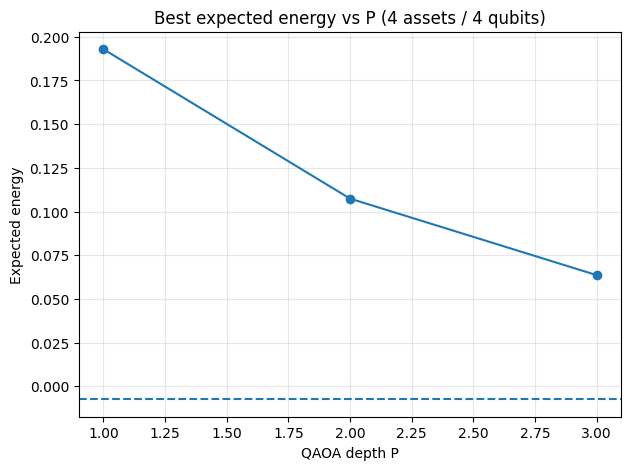

In [6]:
plot_df = summary_df.sort_values("P")

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["expected_energy"], marker="o")
plt.axhline(ground_truth_energy, linestyle="--")
plt.xlabel("QAOA depth P")
plt.ylabel("Expected energy")
plt.title("Best expected energy vs P (4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.show()

**2ST Graph, Runtime vs P**

   P  runtime_sec  expected_energy  energy_loss  ground_truth_probability
0  1     2.541298         0.192856     0.200270                  0.111161
1  2    39.434532         0.107383     0.114797                  0.129213
2  3    92.101490         0.063600     0.071014                  0.170518


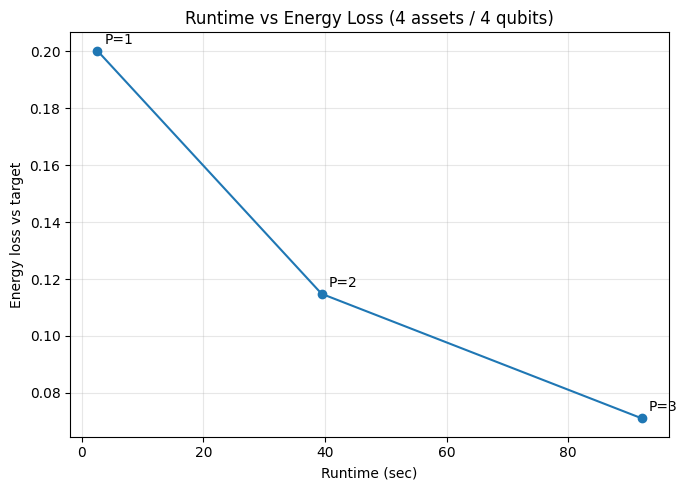

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

target_energy = -0.007413805245517935

plot_df = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "expected_energy": r["expected_energy"],
        "energy_loss": r["expected_energy"] - target_energy,
        "ground_truth_probability": r["ground_truth_probability"],
    }
    for r in experiment_results
]).sort_values("P").reset_index(drop=True)

print(plot_df)

plt.figure(figsize=(7,5))
plt.plot(plot_df["runtime_sec"], plot_df["energy_loss"], marker="o")
for _, row in plot_df.iterrows():
    plt.annotate(f'P={int(row["P"])}', (row["runtime_sec"], row["energy_loss"]), xytext=(5,5), textcoords="offset points")
plt.xlabel("Runtime (sec)")
plt.ylabel("Energy loss vs target")
plt.title("Runtime vs Energy Loss (4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Qubit plot**

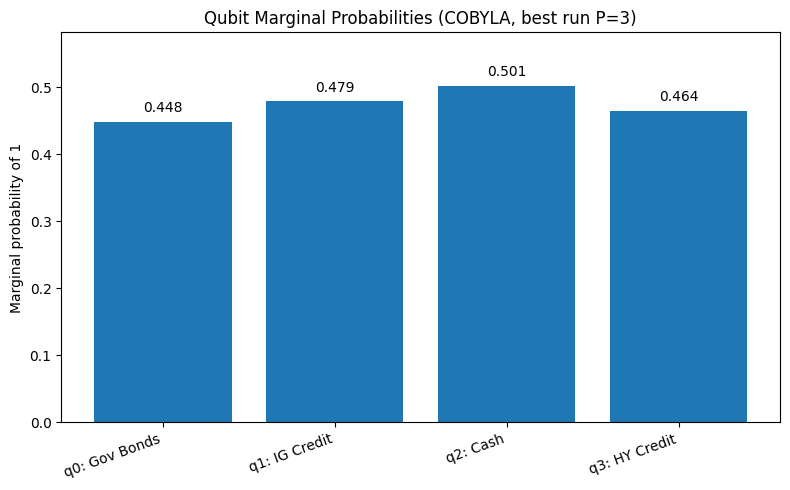

Best COBYLA run P = 3
Best gamma = [3.525412676855067, 2.0544742032872954, 3.0984011604710435]
Best beta = [2.1006125514579654, 0.6506773823377708, 0.7867087680130788]
Expected energy = 0.0636002314711283
Ground-truth probability = 0.17051801143726103
Top bitstring = 0011
Top probability = 0.17051801143726103


In [27]:
import numpy as np
import matplotlib.pyplot as plt

best_idx = max(
    range(len(experiment_results)),
    key=lambda i: experiment_results[i]["ground_truth_probability"]
)
best_run = experiment_results[best_idx]

probs_opt = best_run["probs_opt"]
n_qubits_local = n_qubits

marginals = np.zeros(n_qubits_local, dtype=float)

for idx, p in enumerate(probs_opt):
    bitstring = format(idx, f"0{n_qubits_local}b")
    for q in range(n_qubits_local):
        if bitstring[q] == "1":
            marginals[q] += p

qubit_labels = [
    "q0: Gov Bonds",
    "q1: IG Credit",
    "q2: Cash",
    "q3: HY Credit",
]

plt.figure(figsize=(8,5))
bars = plt.bar(range(n_qubits_local), marginals)

plt.xticks(range(n_qubits_local), qubit_labels, rotation=20, ha="right")
plt.ylabel("Marginal probability of 1")
plt.title(f'Qubit Marginal Probabilities (COBYLA, best run P={best_run["P"]})')
plt.ylim(0, max(marginals) + 0.08)

for bar, val in zip(bars, marginals):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print("Best COBYLA run P =", best_run["P"])
print("Best gamma =", best_run["best_gamma"])
print("Best beta =", best_run["best_beta"])
print("Expected energy =", best_run["expected_energy"])
print("Ground-truth probability =", best_run["ground_truth_probability"])
print("Top bitstring =", best_run["top_bitstring"])
print("Top probability =", best_run["top_probability"])

# P [1,2,3] , Optimizer = Powell

In [19]:
import numpy as np

# ===== 4 assets / 4 qubits corrected Ising Hamiltonian =====
n_qubits = 4

h_terms = np.array([
    0.028200,
    0.016020,
    0.035460,
    0.006839
], dtype=float)

J_terms = np.zeros((4, 4), dtype=float)
J_terms[0,1] = 0.120003
J_terms[0,2] = 0.250002
J_terms[0,3] = 0.060001
J_terms[1,2] = 0.150001
J_terms[1,3] = 0.036002
J_terms[2,3] = 0.075002

J_terms[1,0] = J_terms[0,1]
J_terms[2,0] = J_terms[0,2]
J_terms[3,0] = J_terms[0,3]
J_terms[2,1] = J_terms[1,2]
J_terms[3,1] = J_terms[1,3]
J_terms[3,2] = J_terms[2,3]

ising_offset = 0.295508
ground_truth_bits = "0011"

print("4Q Hamiltonian loaded.")
print("n_qubits =", n_qubits)
print("h_terms shape =", h_terms.shape)
print("J_terms shape =", J_terms.shape)
print("ground_truth_bits =", ground_truth_bits)
print("ising_offset =", ising_offset)

4Q Hamiltonian loaded.
n_qubits = 4
h_terms shape = (4,)
J_terms shape = (4, 4)
ground_truth_bits = 0011
ising_offset = 0.295508


In [20]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from bloqade.pyqrack import StackMemorySimulator

# =========================================================
# MULTI-P RUNNER WITH POWELL
# Assumes already defined:
# - n_qubits
# - h_terms
# - J_terms
# - ising_offset
# - ground_truth_bits
# - build_qaoa_ising_kernel(...)
# =========================================================

# -------- freeze Hamiltonian once --------
h_base = np.array(h_terms, dtype=float).reshape(-1).copy()
J_base = np.array(J_terms, dtype=float).copy()

assert h_base.shape == (n_qubits,), f"h_base shape inesperada: {h_base.shape}"
assert J_base.shape == (n_qubits, n_qubits), f"J_base shape inesperada: {J_base.shape}"

print("Frozen h_base shape:", h_base.shape)
print("Frozen J_base shape:", J_base.shape)

# -------- Bloqade-format terms --------
h_kernel_terms = [(i, float(h_base[i])) for i in range(n_qubits)]

J_kernel_terms = []
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        if abs(J_base[i, j]) > 1e-12:
            J_kernel_terms.append((i, j, float(J_base[i, j])))

print("h_kernel_terms =", h_kernel_terms)
print("J_kernel_terms =", J_kernel_terms)

# -------- build kernel + simulator --------
kernel = build_qaoa_ising_kernel(
    n_qubits=n_qubits,
    h_terms=h_kernel_terms,
    J_terms=J_kernel_terms
)

sim = StackMemorySimulator(min_qubits=n_qubits)

# -------- helper functions --------
def join_theta(gamma_vals, beta_vals):
    return np.array(list(gamma_vals) + list(beta_vals), dtype=float)

def split_theta(theta, p):
    theta = np.array(theta, dtype=float)
    gamma_vals = theta[:p].tolist()
    beta_vals = theta[p:2*p].tolist()
    return gamma_vals, beta_vals

def ising_energy_from_x_list_local(x_list, h_local, J_local, const=0.0):
    x = np.array(x_list, dtype=int)
    s = 2 * x - 1
    e = 0.0

    for i in range(len(s)):
        e += float(h_local[i]) * s[i]

    for i in range(len(s)):
        for j in range(i + 1, len(s)):
            e += float(J_local[i, j]) * s[i] * s[j]

    return float(e + const)

def sample_counts_from_probs(probs, shots=1000, seed=123):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(probs))
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()
    sampled = rng.choice(indices, size=shots, p=probs)

    counts = {}
    for idx in sampled:
        bitstring = format(idx, f"0{n_qubits}b")
        counts[bitstring] = counts.get(bitstring, 0) + 1

    return dict(sorted(counts.items(), key=lambda kv: kv[1], reverse=True))

# -------- experiment settings --------
P_values = [1, 2, 3]

METHOD = "Powell"
MAXITER = 5000
XTOL = 1e-4
FTOL = 1e-4
SHOTS = 2000
SEED = 123

experiment_results_powell = []

for P in P_values:
    print(f"\n========== RUNNING POWELL, P={P} ==========")
    t0 = time.time()

    INITIAL_POINTS = [
        ([0.3] * P, [0.2] * P),
        ([0.5] * P, [0.5] * P),
        ([1.0] * P, [0.5] * P),
        ([2.0] * P, [1.0] * P),
        ([np.pi / 2] * P, [np.pi / 4] * P),
    ]

    def probs_from_theta(theta):
        gamma_vals, beta_vals = split_theta(theta, P)
        ket = sim.state_vector(kernel, args=(gamma_vals, beta_vals))
        probs = np.abs(np.array(ket)) ** 2
        probs = probs / probs.sum()
        return probs

    def expected_ising_energy_for_theta(theta):
        probs = probs_from_theta(theta)
        exp_energy = 0.0
        for idx in range(2 ** n_qubits):
            bitstring = format(idx, f"0{n_qubits}b")
            x_list = [int(b) for b in bitstring]
            energy = ising_energy_from_x_list_local(x_list, h_base, J_base, ising_offset)
            exp_energy += probs[idx] * energy
        return float(exp_energy)

    def optimize_once(theta0):
        def objective(theta):
            return expected_ising_energy_for_theta(theta)

        result = minimize(
            objective,
            theta0,
            method=METHOD,
            options={"maxiter": MAXITER, "xtol": XTOL, "ftol": FTOL}
        )
        return result

    best_result = None
    best_theta0 = None

    for gamma0, beta0 in INITIAL_POINTS:
        theta0 = join_theta(gamma0, beta0)
        result = optimize_once(theta0)

        if best_result is None or result.fun < best_result.fun:
            best_result = result
            best_theta0 = theta0

    best_gamma, best_beta = split_theta(best_result.x, P)

    ket_opt = sim.state_vector(kernel, args=(best_gamma, best_beta))
    probs_opt = np.abs(np.array(ket_opt)) ** 2
    probs_opt = probs_opt / probs_opt.sum()

    gt_index = int(ground_truth_bits, 2)
    gt_prob = float(probs_opt[gt_index])

    top_index = int(np.argmax(probs_opt))
    top_bitstring = format(top_index, f"0{n_qubits}b")

    runtime_sec = time.time() - t0

    experiment_results_powell.append({
        "P": P,
        "runtime_sec": runtime_sec,
        "best_theta0": best_theta0.copy(),
        "best_gamma": best_gamma,
        "best_beta": best_beta,
        "best_fun": float(best_result.fun),
        "expected_energy": float(best_result.fun),
        "ground_truth_probability": gt_prob,
        "top_bitstring": top_bitstring,
        "top_probability": float(probs_opt[top_index]),
        "probs_opt": probs_opt.copy(),
        "counts": sample_counts_from_probs(probs_opt, shots=SHOTS, seed=SEED),
        "optimizer": "Powell",
    })

    print(f"P={P} done")
    print("  best_gamma =", best_gamma)
    print("  best_beta =", best_beta)
    print("  expected_energy =", float(best_result.fun))
    print("  ground_truth_probability =", gt_prob)
    print("  top_bitstring =", top_bitstring)
    print("  top_probability =", float(probs_opt[top_index]))
    print("  runtime_sec =", runtime_sec)

Frozen h_base shape: (4,)
Frozen J_base shape: (4, 4)
h_kernel_terms = [(0, 0.0282), (1, 0.01602), (2, 0.03546), (3, 0.006839)]
J_kernel_terms = [(0, 1, 0.120003), (0, 2, 0.250002), (0, 3, 0.060001), (1, 2, 0.150001), (1, 3, 0.036002), (2, 3, 0.075002)]

========== RUNNING POWELL, P=1 ==========
P=1 done
  best_gamma = [1.6777207101188525]
  best_beta = [1.289039660718867]
  expected_energy = 0.19285609350093627
  ground_truth_probability = 0.1111930599924679
  top_bitstring = 1100
  top_probability = 0.11721267941145659
  runtime_sec = 1.7795283794403076

========== RUNNING POWELL, P=2 ==========
P=2 done
  best_gamma = [3.6739249672614442, 3.28132743995248]
  best_beta = [0.9120525343009688, 1.055929197045647]
  expected_energy = 0.10737622136392738
  ground_truth_probability = 0.12930520869771295
  top_bitstring = 1010
  top_probability = 0.17440721325076627
  runtime_sec = 10.328913450241089

========== RUNNING POWELL, P=3 ==========
P=3 done
  best_gamma = [3.5559966696779544, 2.0

In [29]:
ground_state_bitstring = ground_truth_bits
ground_state_energy = -0.007413805245517935

print("===================================")
print("CLASSICAL TARGET")
print("===================================")
print("Ground-state bitstring :", ground_state_bitstring)
print("Ground-state energy    :", ground_state_energy)

print("\n===================================")
print("POWELL QAOA vs TARGET")
print("===================================")

for r in experiment_results_powell:
    gap_to_target = r["expected_energy"] - ground_state_energy
    print(f"P={r['P']}")
    print(f"  expected_energy          = {r['expected_energy']:.9f}")
    print(f"  target_energy            = {ground_state_energy:.9f}")
    print(f"  energy_gap_to_target     = {gap_to_target:.9f}")
    print(f"  ground_truth_probability = {r['ground_truth_probability']:.9f}")
    print(f"  top_bitstring            = {r['top_bitstring']}")
    print(f"  top_probability          = {r['top_probability']:.9f}")
    print()

CLASSICAL TARGET
Ground-state bitstring : 0011
Ground-state energy    : -0.007413805245517935

POWELL QAOA vs TARGET
P=1
  expected_energy          = 0.192856094
  target_energy            = -0.007413805
  energy_gap_to_target     = 0.200269899
  ground_truth_probability = 0.111193060
  top_bitstring            = 1100
  top_probability          = 0.117212679

P=2
  expected_energy          = 0.107376221
  target_energy            = -0.007413805
  energy_gap_to_target     = 0.114790027
  ground_truth_probability = 0.129305209
  top_bitstring            = 1010
  top_probability          = 0.174407213

P=3
  expected_energy          = 0.063589609
  target_energy            = -0.007413805
  energy_gap_to_target     = 0.071003414
  ground_truth_probability = 0.170649149
  top_bitstring            = 0011
  top_probability          = 0.170649149



In [21]:
summary_df_powell = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "best_fun": r["best_fun"],
        "expected_energy": r["expected_energy"],
        "ground_truth_probability": r["ground_truth_probability"],
        "top_bitstring": r["top_bitstring"],
        "top_probability": r["top_probability"],
        "optimizer": r["optimizer"],
    }
    for r in experiment_results_powell
])

summary_df_powell.sort_values("P").reset_index(drop=True)

,P,runtime_sec,best_fun,expected_energy,ground_truth_probability,top_bitstring,top_probability,optimizer
0,1,1.779528,0.192856,0.192856,0.111193,1100,0.117213,Powell
1,2,10.328913,0.107376,0.107376,0.129305,1010,0.174407,Powell
2,3,35.192200,0.063590,0.063590,0.170649,0011,0.170649,Powell


   P  expected_energy  energy_loss  runtime_sec  ground_truth_probability
0  1         0.192856     0.200270     2.541298                  0.111161
1  2         0.107383     0.114797    39.434532                  0.129213
2  3         0.063600     0.071014    92.101490                  0.170518


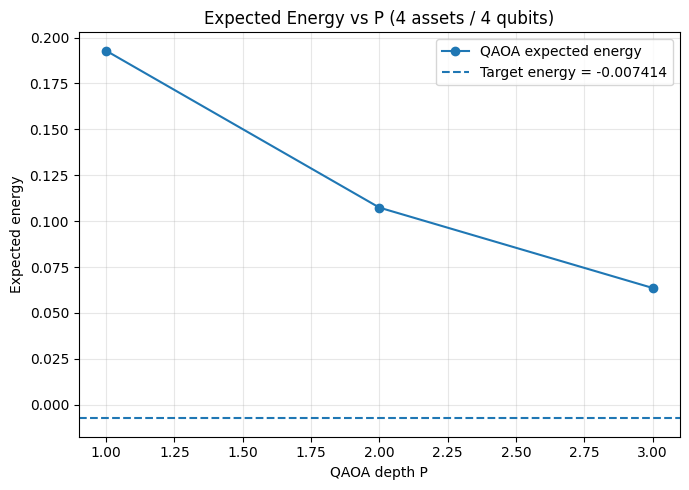

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

target_energy = -0.007413805245517935

plot_df = pd.DataFrame([
    {
        "P": r["P"],
        "expected_energy": r["expected_energy"],
        "energy_loss": r["expected_energy"] - target_energy,
        "runtime_sec": r["runtime_sec"],
        "ground_truth_probability": r["ground_truth_probability"],
    }
    for r in experiment_results
]).sort_values("P").reset_index(drop=True)

print(plot_df)

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["expected_energy"], marker="o", label="QAOA expected energy")
plt.axhline(target_energy, linestyle="--", label=f"Target energy = {target_energy:.6f}")
plt.xlabel("QAOA depth P")
plt.ylabel("Expected energy")
plt.title("Expected Energy vs P (4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

   P  runtime_sec  expected_energy  energy_loss  ground_truth_probability
0  1     1.779528         0.192856     0.200270                  0.111193
1  2    10.328913         0.107376     0.114790                  0.129305
2  3    35.192200         0.063590     0.071003                  0.170649


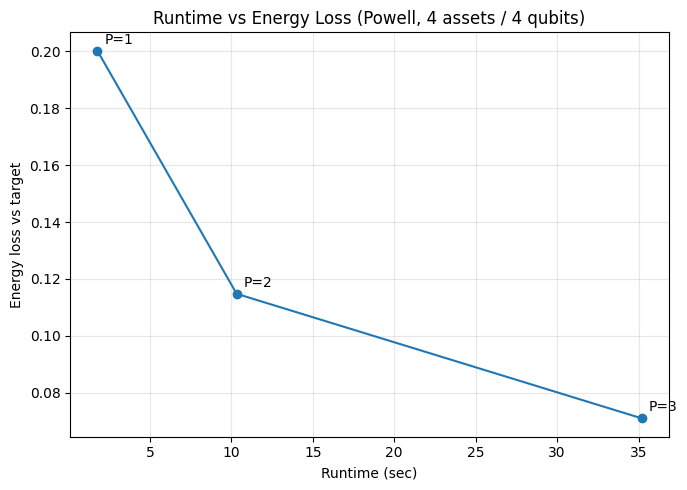

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

target_energy = -0.007413805245517935

plot_df_powell = pd.DataFrame([
    {
        "P": r["P"],
        "runtime_sec": r["runtime_sec"],
        "expected_energy": r["expected_energy"],
        "energy_loss": r["expected_energy"] - target_energy,
        "ground_truth_probability": r["ground_truth_probability"],
    }
    for r in experiment_results_powell
]).sort_values("P").reset_index(drop=True)

print(plot_df_powell)

plt.figure(figsize=(7,5))
plt.plot(plot_df_powell["runtime_sec"], plot_df_powell["energy_loss"], marker="o")
for _, row in plot_df_powell.iterrows():
    plt.annotate(f'P={int(row["P"])}', (row["runtime_sec"], row["energy_loss"]), xytext=(5,5), textcoords="offset points")
plt.xlabel("Runtime (sec)")
plt.ylabel("Energy loss vs target")
plt.title("Runtime vs Energy Loss (Powell, 4 assets / 4 qubits)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

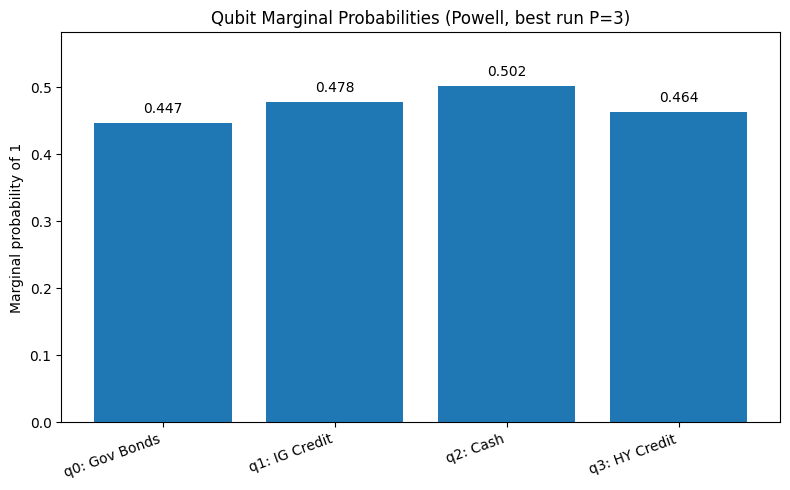

Best Powell run P = 3
Best gamma = [3.5559966696779544, 2.0636937300669183, 3.102645344237603]
Best beta = [2.104639399937136, 0.653188006042398, 0.7833841208690105]
Expected energy = 0.06358960911527332
Ground-truth probability = 0.17064914924357136
Top bitstring = 0011
Top probability = 0.17064914924357136


In [28]:
import numpy as np
import matplotlib.pyplot as plt

best_idx_powell = max(
    range(len(experiment_results_powell)),
    key=lambda i: experiment_results_powell[i]["ground_truth_probability"]
)
best_run_powell = experiment_results_powell[best_idx_powell]

probs_opt = best_run_powell["probs_opt"]
n_qubits_local = n_qubits

marginals = np.zeros(n_qubits_local, dtype=float)

for idx, p in enumerate(probs_opt):
    bitstring = format(idx, f"0{n_qubits_local}b")
    for q in range(n_qubits_local):
        if bitstring[q] == "1":
            marginals[q] += p

qubit_labels = [
    "q0: Gov Bonds",
    "q1: IG Credit",
    "q2: Cash",
    "q3: HY Credit",
]

plt.figure(figsize=(8,5))
bars = plt.bar(range(n_qubits_local), marginals)

plt.xticks(range(n_qubits_local), qubit_labels, rotation=20, ha="right")
plt.ylabel("Marginal probability of 1")
plt.title(f'Qubit Marginal Probabilities (Powell, best run P={best_run_powell["P"]})')
plt.ylim(0, max(marginals) + 0.08)

for bar, val in zip(bars, marginals):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print("Best Powell run P =", best_run_powell["P"])
print("Best gamma =", best_run_powell["best_gamma"])
print("Best beta =", best_run_powell["best_beta"])
print("Expected energy =", best_run_powell["expected_energy"])
print("Ground-truth probability =", best_run_powell["ground_truth_probability"])
print("Top bitstring =", best_run_powell["top_bitstring"])
print("Top probability =", best_run_powell["top_probability"])

# **Visualize the circuits using Qiskit, only the best runs with the respective parameters already trained**

### **COBYLA**

### **Powell**